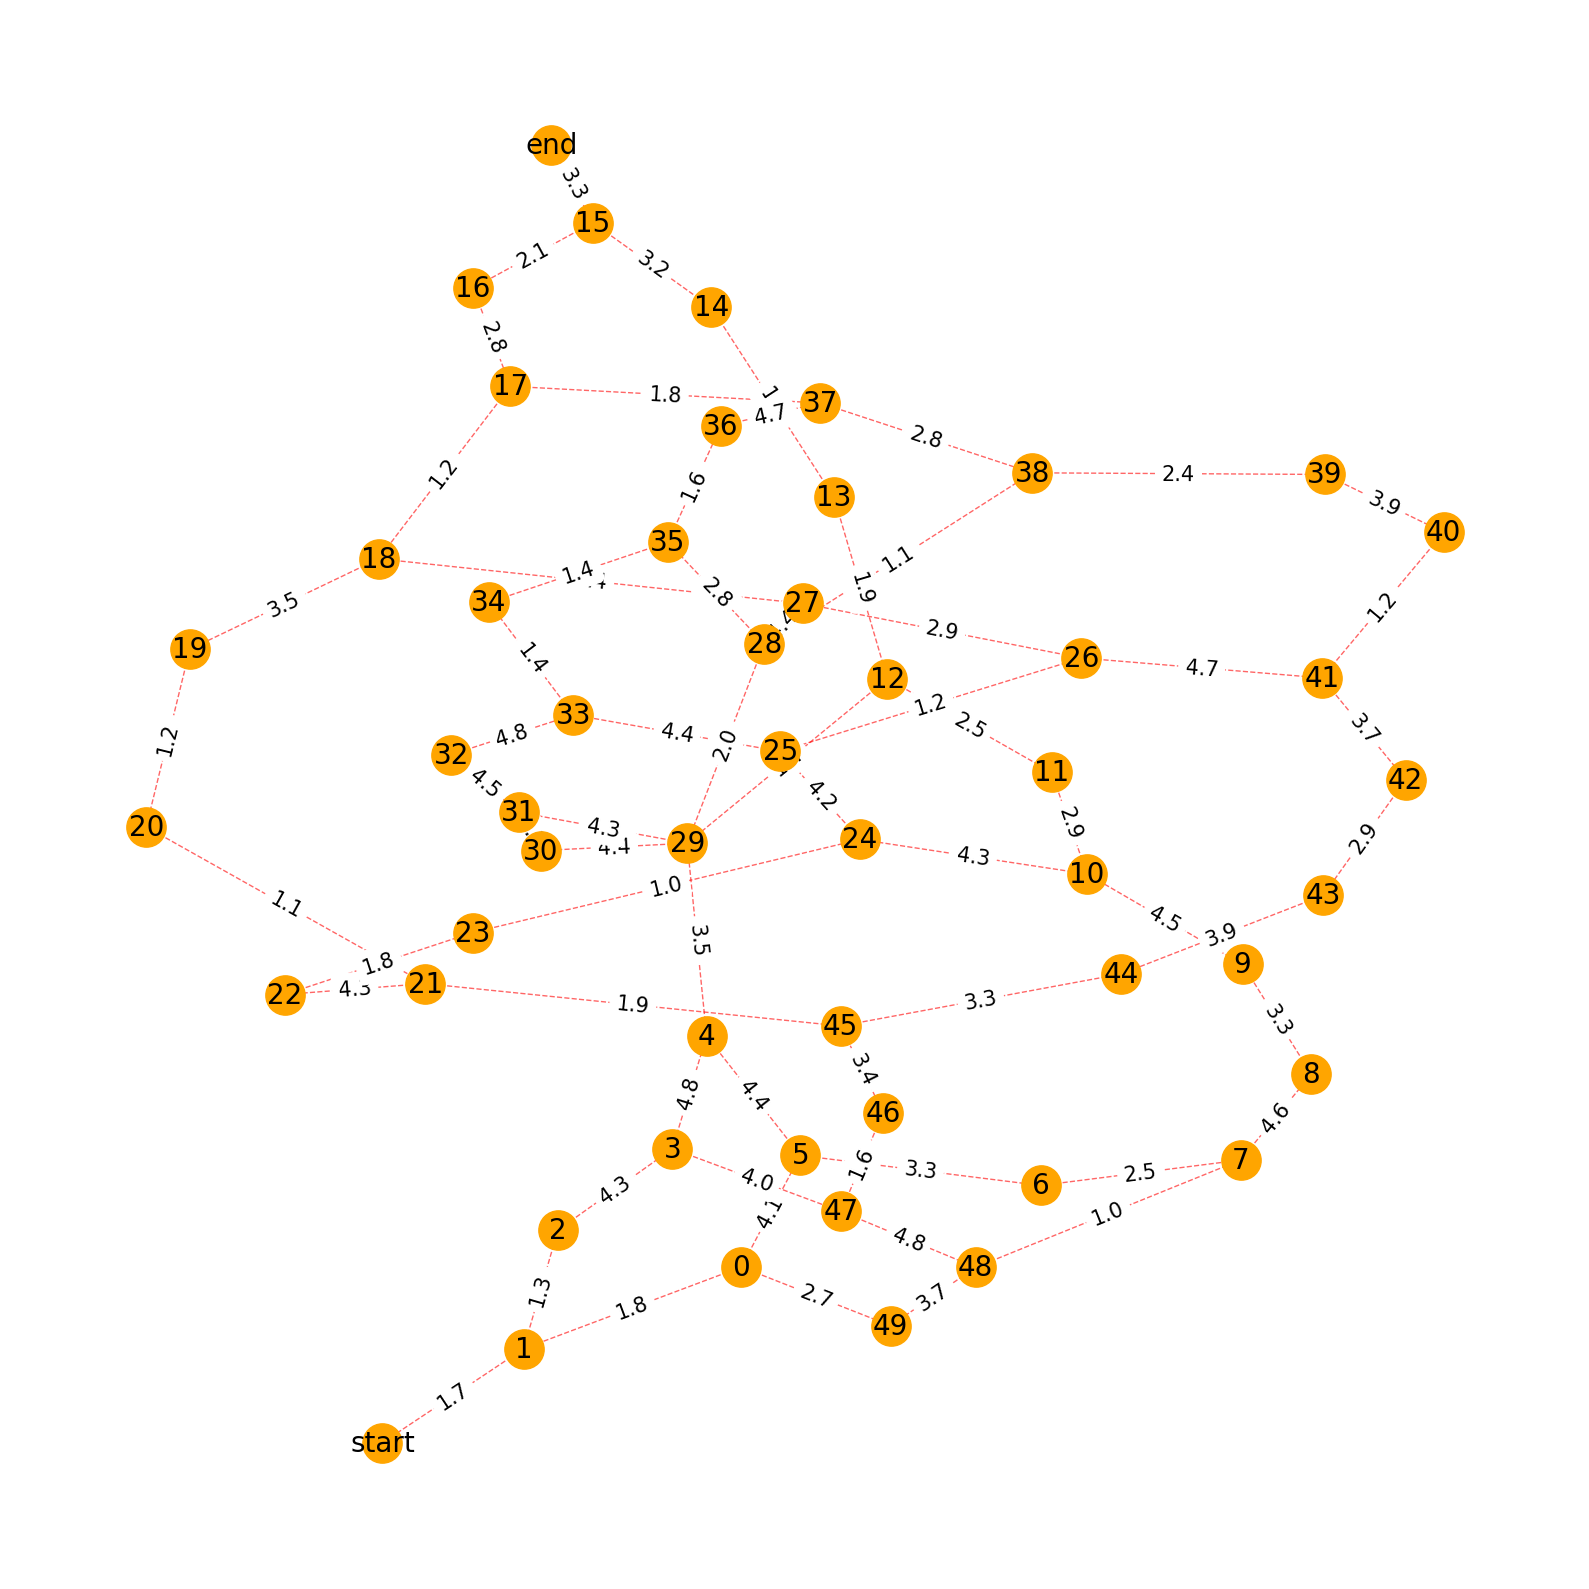

In [13]:
import networkx as nx
import random, decimal
import pylab as plt


random.seed()
nodes = random.randint(5,25)
seed = random.randint(2,3)
probability = random.random()

num=50
G = nx.newman_watts_strogatz_graph(num,seed,0.33767,seed=None)
G.add_node("start")
G.add_node("end")
G.add_edge("start",1)
G.add_edge("end",15)

for (u, v) in G.edges():
    G.edges[u,v]['weight'] = float(decimal.Decimal(random.randrange(10, 50))/10)
degree_sequence = sorted((d for n, d in G.degree()), reverse=True)
dmax = max(degree_sequence)
fig = plt.figure("Degree of a random graph", figsize=(16,16))

Gcc = G.subgraph(sorted(nx.connected_components(G), key=len, reverse=True)[0])

pos = nx.spring_layout(Gcc, seed=10396953)
nx.draw_networkx_nodes(Gcc, pos, node_size=800,node_color="orange")
nx.draw_networkx_edges(Gcc, pos, alpha=0.6,edge_color="r",style="dashed")

nx.draw_networkx_labels(Gcc,pos,font_size=20)
edge_labels=nx.get_edge_attributes(Gcc,"weight")
nx.draw_networkx_edge_labels(Gcc,pos,edge_labels,font_size=15)

plt.axis("off")
plt.tight_layout()
plt.show()

In [5]:
ax1 = fig.add_subplot(axgrid[3:, :2])
ax1.plot(degree_sequence, "b-", marker="o")
ax1.set_title("Degree Distribution Plot (2000 nodes)")
ax1.set_ylabel("Degree")
ax1.set_xlabel("Node Count")
plt.show()

In [9]:
import numpy as np
ax2 = fig.add_subplot(axgrid[3:, 2:])
ax2.bar(*np.unique(degree_sequence, return_counts=True))
ax2.set_title("Degree histogram")
ax2.set_xlabel("Degree")
ax2.set_ylabel("Node Count")
plt.show()

c:\users\91938\appdata\local\programs\python\python37\lib\site-packages\ipykernel_launcher.py:2: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  


In [17]:
graph = G
goal = "end"
visited = set() 

def dfs(visited, graph, node):
    if node not in visited:
        print (node)
        visited.add(node)
        for neighbour in graph[node]:
            if goal in visited:
                break
            else:
                dfs(visited, graph, neighbour)
dfs(visited, graph,"start")

start
1
0
49
48
47
46
45
44
43
42
41
40
39
38
37
36
35
34
33
32
31
30
29
28
27
26
25
24
23
22
21
20
19
18
17
16
15
14
13
12
11
10
9
8
7
6
5
4
3
2
end


In [19]:
graph=G
temp = []
temp1 = []
for i in graph:
  temp.append(i[0])
  temp1.append(i[1])
nodes = set(temp).union(set(temp1))
def UCS(graph, costs, open, closed, cur_node):
  if cur_node in open:
    open.remove(cur_node)
  closed.add(cur_node)
  for i in graph:
    if(i[0] == cur_node and costs[i[0]]+i[2] < costs[i[1]]):
      open.add(i[1])
      costs[i[1]] = costs[i[0]]+i[2]
      path[i[1]] = path[i[0]] + ' -> ' + i[1]
  costs[cur_node] = 999999
  small = min(costs, key=costs.get)
  if small not in closed:
    UCS(graph, costs, open,closed, small)
costs = dict()
temp_cost = dict()
path = dict()
for i in nodes:
  costs[i] = 999999
  path[i] = ' '
open = set()
closed = set()
start_node = input("Enter the Start State: ")
open.add(start_node)
path[start_node] = start_node
costs[start_node] = 0
UCS(graph, costs, open, closed, start_node)
goal_node = input("Enter the Goal State: ")
print("Path with least cost is: ",path[goal_node])

TypeError: 'int' object is not subscriptable